QSO_SED

Text(0.5, 1.0, 'QSO SED')

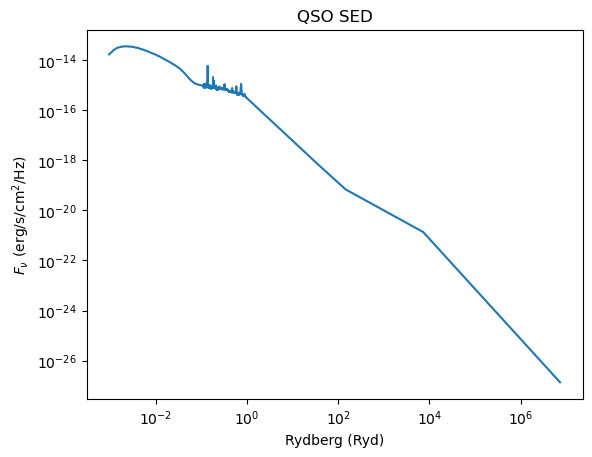

In [1]:
from RT_v1 import *

Lumin = 44.0
Column_density_order= 22.0
metals = 1.0

path_SED = os.path.expanduser(f'~/CIV_RT_scat_data/CLOUDY_setup/Lum_{Lumin}_2/metal_{metals}/N_H_1.0_{Column_density_order}/CIV')
Ryd, Fnu = QSO_SED(path_SED)
plt.plot(Ryd, Fnu, label='QSO SED')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Rydberg (Ryd)')
plt.ylabel(r'$F_{\nu} ~ \rm (erg/s/cm^2/Hz)$')
plt.title('QSO SED')



[]
continuum is 5.903049172117866e+42
lambda_c [cm] = 1.5491475008516436e-05
lambda_c [A] = 1549.1475008516436
Llambda peak = 1.0971840958111417e+43
Sigma Lambda = 15.5 Angstrom
Peak/Continuum excess ratio = 8.59e-01
Gaussian EW = 33.36655025872171 Angstrom
Direct EW = 17.836906642814874 Angstrom
Direct Jin EW = 28.151591143039308 Angstrom


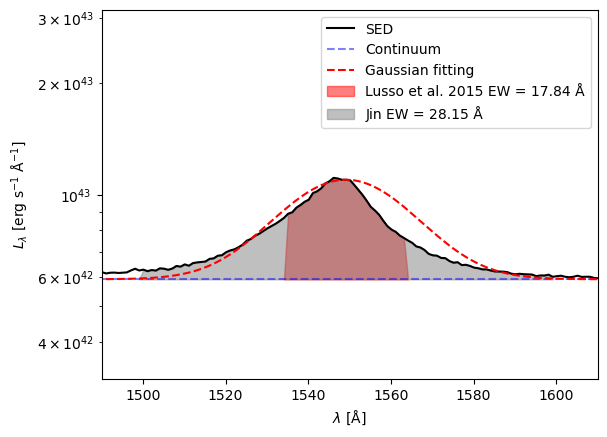

In [2]:
from RT_v1 import *

Lumin = 46.0
idx_2 = 2
metals = 0.1
Column_density_order = 22.0

path_SED = os.path.expanduser(f'~/CIV_RT_scat_data/CLOUDY_setup/Lum_{Lumin}_2/metal_{metals}/N_H_1.0_{Column_density_order}/CIV')
Ryd, Fnu = QSO_SED(path_SED)


nu = Ryd * 13.6 / h_ev  # Hz
nuFnu = Fnu * nu

# floating-point 문제 방지
idx_1ryd = np.argmin(np.abs(Ryd - 1.0))
normalized_factor = 10**Lumin / nuFnu[idx_1ryd]

Lnu = Fnu * normalized_factor  # erg/s/Hz
nuLnu = Lnu * nu               # erg/s

lambda_cm = c_cms / nu
lambda_A = lambda_cm * 1e8

Llambda = Lnu * c_cms / lambda_cm**2 * 1e-8  # erg/s/A


# =====================================================
# 1. Continuum estimate
# CIV line 중심부를 피해서 continuum window 사용
# =====================================================

cont_mask = (
    ((lambda_A >= 1450) & (lambda_A <= 1470)) 
    # ((lambda_A >= 1570) & (lambda_A <= 1600))
)

aa = np.where(lambda_A ==1450)
print(Llambda[aa])
Lc = np.median(Llambda[cont_mask])
print("continuum is", Lc)


# =====================================================
# 2. CIV peak 찾기
# =====================================================

peak_mask = (lambda_A > 1548) & (lambda_A <= 1551)
peak_indices = np.where(peak_mask)[0]

peak_idx = peak_indices[np.argmax(Llambda[peak_indices])]

Llambda_max = Llambda[peak_idx]
lambda_c = lambda_cm[peak_idx]

print("lambda_c [cm] =", lambda_c)
print("lambda_c [A] =", lambda_A[peak_idx])
print("Llambda peak =", Llambda_max)


# =====================================================
# 3. Gaussian EW estimate
# sig_vel이 sigma velocity일 때만 이 식 사용
# =====================================================

def EW_gaussian(Fc, F_max, lam_c, sig_vel):
    sigma_lam = sig_vel / c_kms * lam_c

    print(f"Sigma Lambda = {sigma_lam * 1e8:.1f} Angstrom")

    amp_ratio = (F_max - Fc) / Fc

    print(f"Peak/Continuum excess ratio = {amp_ratio:.2e}")

    ew_cm = amp_ratio * np.sqrt(2*np.pi) * sigma_lam

    return ew_cm




sig_vel = 3000  # km/s; Gaussian sigma velocity라고 가정

ew_gauss_A = EW_gaussian(Lc, Llambda_max, lambda_c, sig_vel) * 1e8

print("Gaussian EW =", ew_gauss_A, "Angstrom")


# =====================================================
# 4. Gaussian profile
# =====================================================

def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / (2*del_lam**2)) + Fc
    return Flux



F_flux = Flux(Lc, Llambda_max, lambda_cm, lambda_c, sig_vel)


# =====================================================
# 5. Direct integration EW
# =====================================================

from scipy.integrate import simpson

# line_mask = (lambda_A >= 1534) & (lambda_A <= 1564)
dA = 15
line_mask = (lambda_A >= lambda_A[peak_idx] - dA ) & (lambda_A <= lambda_A[peak_idx] + dA )
Lusso_low, Lusso_max = lambda_A[peak_idx] - dA, lambda_A[peak_idx] + dA
# lambda_A[peak_idx]
#1549


lam_line_A = lambda_A[line_mask]
Llam_line = Llambda[line_mask]

idx = np.argsort(lam_line_A)

lam_line_A = lam_line_A[idx]
Llam_line = Llam_line[idx]

# emission line만 적분
y_line = np.maximum((Llam_line - Lc) / Lc, 0)

EW_direct_A = simpson(y_line, x=lam_line_A)

print("Direct EW =", EW_direct_A, "Angstrom")

dA = 15
line_mask = (lambda_A >= 1500) & (lambda_A <= 1600)
Jin_low, Jin_max = 1500, 1600
# lambda_A[peak_idx]
#1549


lam_line_J = lambda_A[line_mask]
Llam_line_J = Llambda[line_mask]

idx_J = np.argsort(lam_line_J)

lam_line_J = lam_line_J[idx_J]
Llam_line_J = Llam_line_J[idx_J]

# emission line만 적분
y_line_J = np.maximum((Llam_line_J - Lc) / Lc, 0)

EW_direct_J = simpson(y_line_J, x=lam_line_J)

print("Direct Jin EW =", EW_direct_J, "Angstrom")




# =====================================================
# 6. Plot
# =====================================================

plt.figure()

plt.yscale("log")
# plt.xscale("log")



plt.xlabel(r"$\lambda$ [$\rm \AA$]")
plt.ylabel(r"$L_{\lambda}$ [erg s$^{-1}$ $\rm \AA^{-1}$]")

plt.plot(lambda_A, Llambda, "k-", label="SED")
plt.axhline(
    y=Lc,
    xmin=0,
    xmax=1,
    linestyle="--",
    color="b",
    alpha=0.5,
    label="Continuum"
)

plt.plot(lambda_A, F_flux, "r--", label="Gaussian fitting")



fill_mask = (
    (lambda_A >= Lusso_low) &
    (lambda_A <= Lusso_max) &
    (Llambda >= Lc)
)

plt.fill_between(
    lambda_A,
    Lc,
    Llambda,
    where=fill_mask,
    color="red",
    alpha=0.5,
    interpolate=True,
    label=f"Lusso et al. 2015 EW = {EW_direct_A:.2f} Å"
)

fill_mask = (
    (lambda_A >= Jin_low) &
    (lambda_A <= Jin_max) &
    (Llambda >= Lc)
)

plt.fill_between(
    lambda_A,
    Lc,
    Llambda,
    where=fill_mask,
    color="grey",
    alpha=0.5,
    interpolate=True,
    label=f"Jin EW = {EW_direct_J:.2f} Å"
)

plt.xlim(1490, 1610)
plt.ylim(1e40 * 10**2.5, 1e41 * 10**2.5)


# plt.scatter(lambda_A[peak_idx], Llambda_max, color="r", s=20)

plt.legend()
# plt.show()
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/EW_Lusso_Jin.pdf', bbox_inches='tight')

Spatial_Distribution
- Test

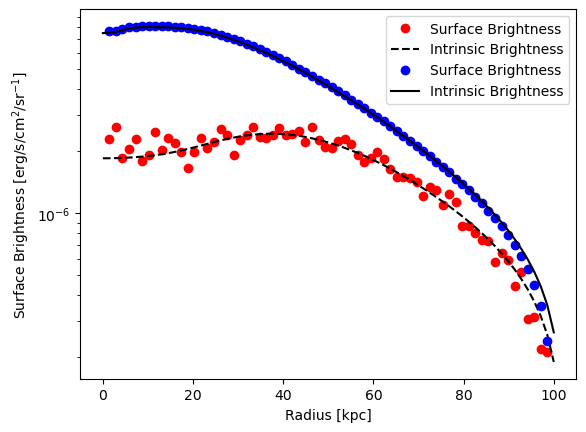

In [3]:
from RT_v1 import *

Lumin = 46.0
Column_density_order= 22.0
metals = 1.0
V_out = 0
V_emit = 3000  # km/s; Gaussian sigma velocity라고 가정
V_rand = 0


path_RT = os.path.expanduser(r"~/CIV_RT_scat_data/SB_CIV")

Lc, EW_direct_J, flux = SED_properties(Lumin, V_emit, metals, Column_density_order)


geo = "test"
atom = "CIV"
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness ,'ro',label='Surface Brightness')

radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',label='Intrinsic Brightness')

atom = "HeII"
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness ,'bo',label='Surface Brightness')

radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',label='Intrinsic Brightness')

plt.yscale("log")
plt.xlabel(r"Radius [kpc]")
plt.ylabel(r"Surface Brightness [erg/s/cm$^2$/sr$^{-1}$]")
plt.legend()    


Spatial_Distribution
- Actual

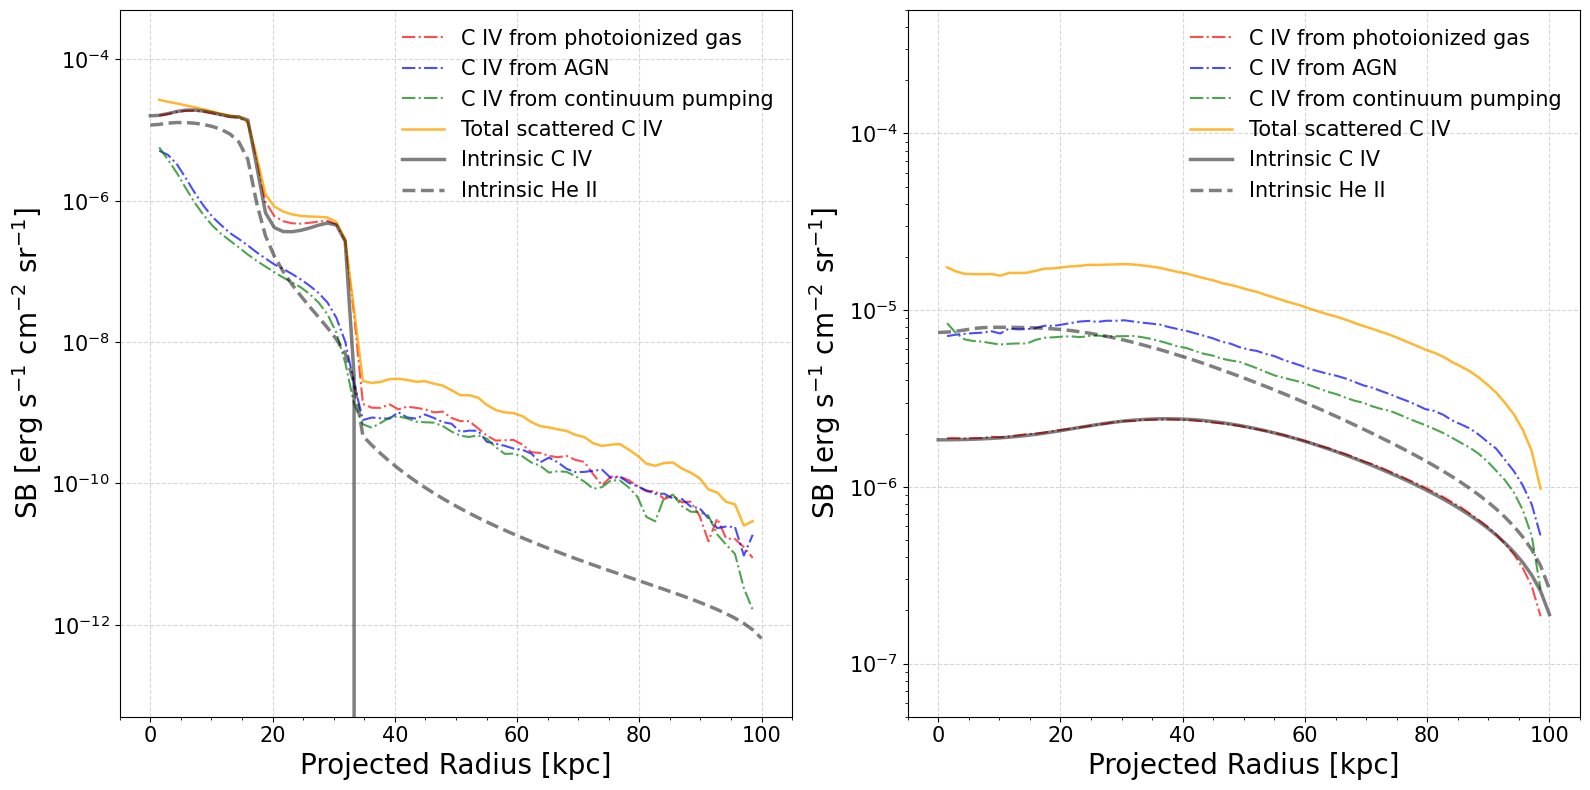

In [4]:
from RT_v1 import *
fig = plt.figure(1,figsize=(16,8))

Column_density_order= 22.0
metals = 1.0
V_out = 500
V_emit = 3000  # km/s; Gaussian sigma velocity라고 가정
V_rand = 30

path_RT = os.path.expanduser(r"~/CIV_RT_scat_data/SB_CIV")


plt.subplot(121)

Lumin = 44.0


Lc, EW_direct_J, flux = SED_properties(Lumin, V_emit, metals, Column_density_order)

Total_CIV = 0

atom = "CIV"

geo = "NEB" 
# path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness ,color='r',linestyle='dashdot',lw=1.5, alpha=0.7,label=fr'C IV from photoionized gas')
Total_CIV += surface_brightness

geo = "QSO" 
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness  ,color='b',linestyle='dashdot',lw=1.5, alpha=0.7,label=fr'C IV from AGN')
Total_CIV += surface_brightness

geo = "Continuum" 
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness ,color='g',linestyle='dashdot', lw=1.5, alpha=0.7,label=fr'C IV from continuum pumping')
Total_CIV += surface_brightness

plt.plot(radius, Total_CIV ,'-',color='orange',alpha=0.8,lw=1.8,label='Total scattered C IV')

radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')



atom = "HeII"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II')





plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.xticks(fontsize=15)

plt.ylabel(r'$\rm SB~[erg \ s^{-1} \ cm^{-2} \ sr^{-1}]$', fontsize=20)
plt.yticks(fontsize=15)
plt.ylim(ymax=5e-4,ymin=5e-14)
plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)
plt.minorticks_on()


plt.subplot(122)

Lumin = 46.0


Lc, EW_direct_J, flux = SED_properties(Lumin, V_emit, metals, Column_density_order)

Total_CIV = 0

atom = "CIV"

geo = "NEB" 
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness ,color='r',linestyle='dashdot',lw=1.5, alpha=0.7,label=fr'C IV from photoionized gas')
Total_CIV += surface_brightness

geo = "QSO" 
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness  ,color='b',linestyle='dashdot',lw=1.5, alpha=0.7,label=fr'C IV from AGN')
Total_CIV += surface_brightness

geo = "Continuum" 
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness ,color='g',linestyle='dashdot', lw=1.5, alpha=0.7,label=fr'C IV from continuum pumping')
Total_CIV += surface_brightness

plt.plot(radius, Total_CIV ,'-',color='orange',alpha=0.8,lw=1.8,label='Total scattered C IV')

radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')



atom = "HeII"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II')





plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.xticks(fontsize=15)


plt.ylabel(r'$\rm SB~[erg \ s^{-1} \ cm^{-2} \ sr^{-1}]$', fontsize=20)
plt.yticks(fontsize=15)
plt.ylim(ymax=5e-4,ymin=5e-8)
plt.yscale('log')



plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)
plt.minorticks_on()
plt.tight_layout()


(1.5040908338785556e-07, 0.001)

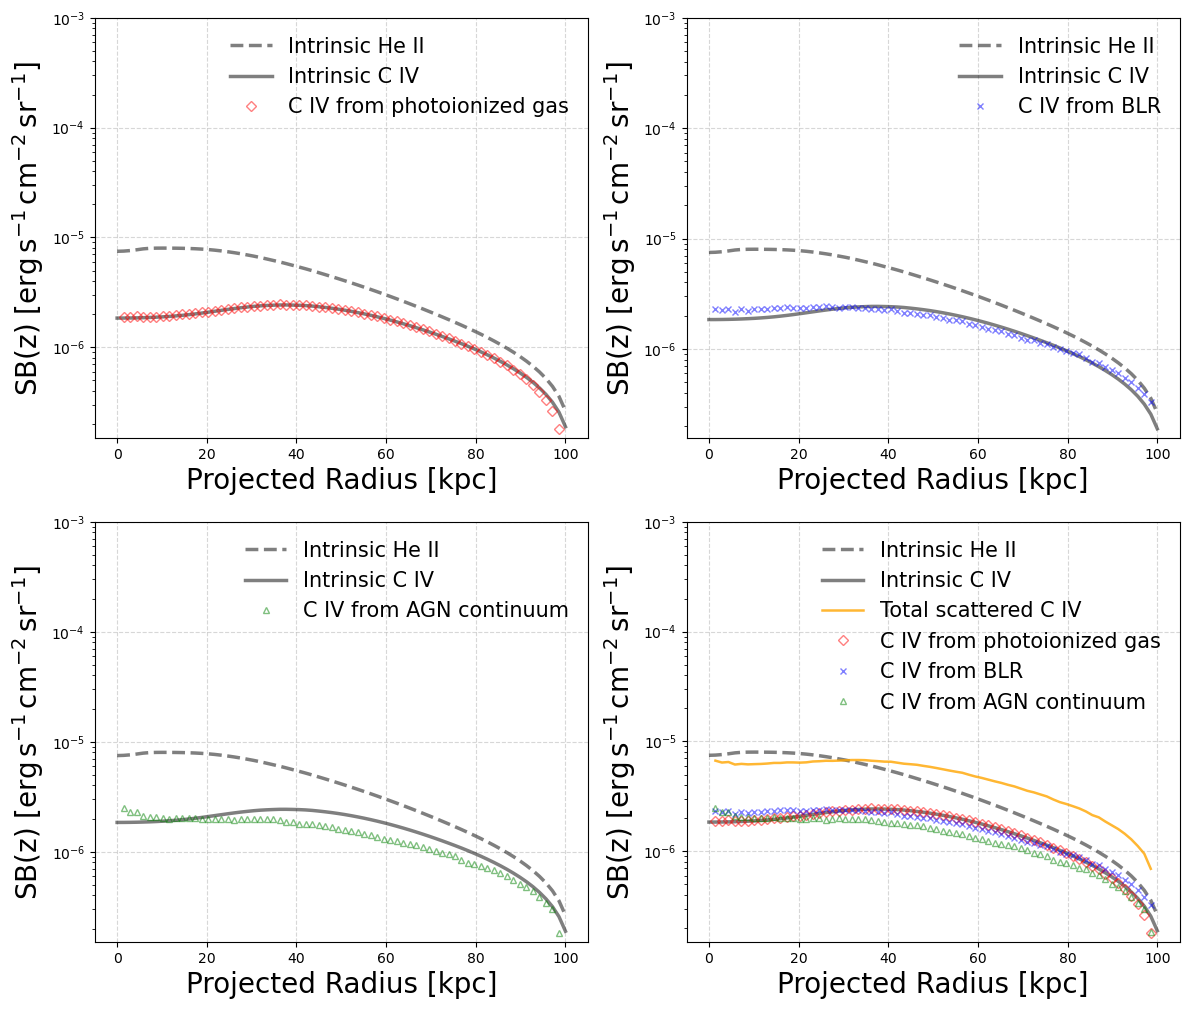

In [5]:
from RT_v1 import *

fig = plt.figure(1,figsize=(14,12))
Lumin = 46.0
idx_2 = 2
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
geo = "Nebula"
V_out = 0
V_emit = 3000
V_rand = 30


path_RT = os.path.expanduser(r"~/CIV_RT_scat_data/SB_CIV")


plt.subplot(221)
geo = "Nebula"

atom = 'HeII'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II ')

atom = 'CIV'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')

geo = "NEB" 
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=fr'C IV from photoionized gas')


plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z)$ $\rm [erg \,s^{-1} \, cm^{-2}\, sr^{-1}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(222)

atom = 'HeII'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II ')

atom = 'CIV'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')

geo = "QSO"
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='x',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=fr'C IV from BLR')

plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z)$ $\rm [erg \,s^{-1} \, cm^{-2} \, sr^{-1}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(223)
atom = 'HeII'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II ')

atom = 'CIV'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')

geo = "Continuum"
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='^',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=fr'C IV from AGN continuum')

plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z)$ $\rm [erg \,s^{-1} \, cm^{-2}\, sr^{-1}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(224)
geo = "Nebula"
atom = 'HeII'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II ')

atom = 'CIV'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')


radius, Total_CIV = total_Scattered_CIV(path_RT, V_out, V_emit, V_rand, Lumin, metals, Column_density_order)
plt.plot(radius, Total_CIV ,'-',color='orange',alpha=0.8,lw=1.8,label='Total scattered C IV')


# plt.plot(globals()[f'radius_{geo}_{Lumin}_{metals}_{Column_density_order}_{V_out}'][1:-1],globals()[f'Total_SB_{Lumin}_{metals}_{Column_density_order}_{V_out}'][1:-1],'-',color='orange',alpha=1.0,lw=3,label='Total scattered C IV')

geo = "NEB" 
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=fr'C IV from photoionized gas')

geo = "QSO"
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='x',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=fr'C IV from BLR')

geo = "Continuum"
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='^',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=fr'C IV from AGN continuum')

plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z)$ $\rm [erg \,s^{-1} \, cm^{-2}\, sr^{-1}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/L_455_M_0100_V_500', bbox_inches='tight')

(1.4725806859294108e-07, 0.001)

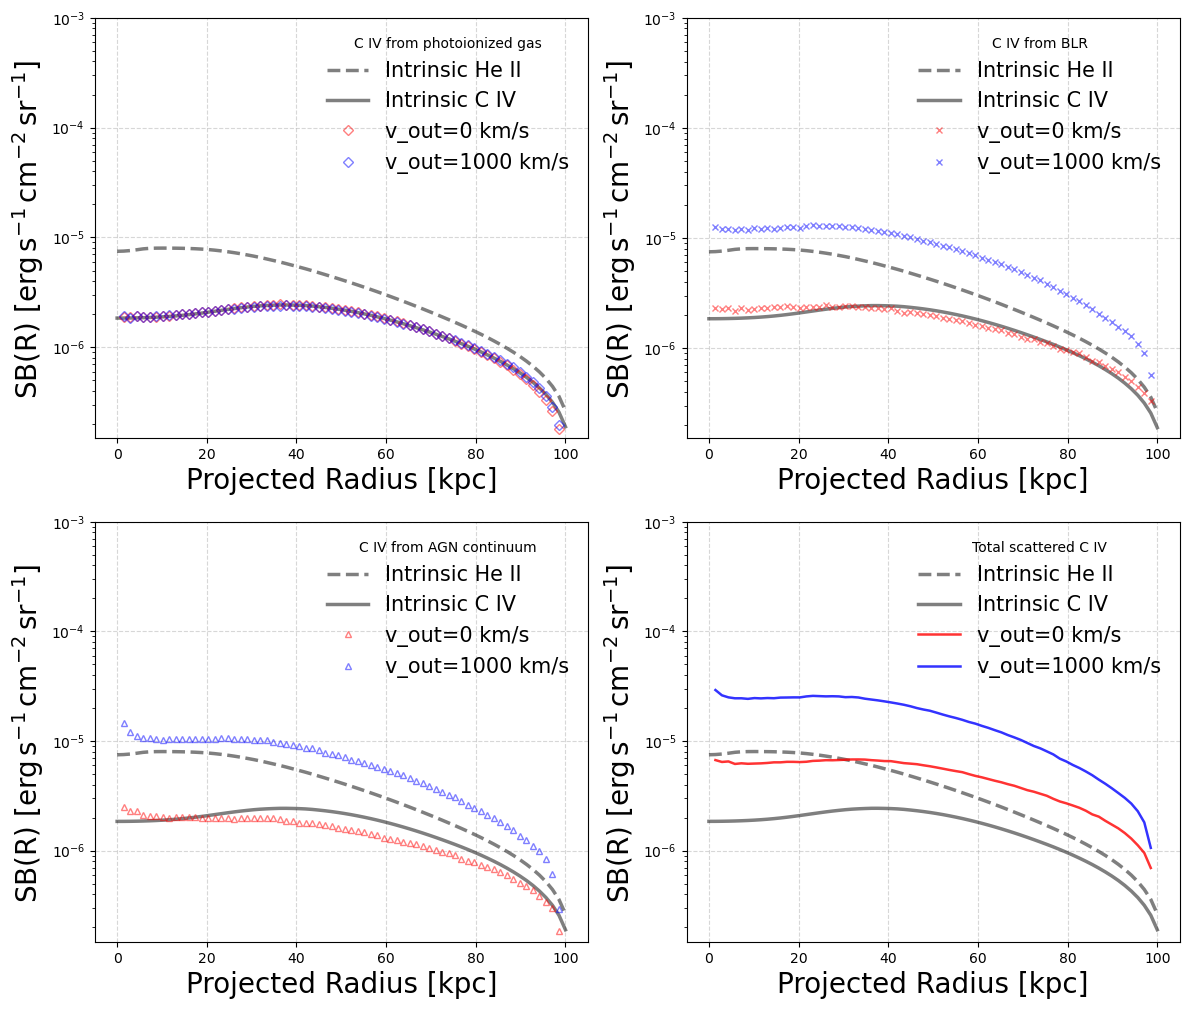

In [6]:
from RT_v1 import *

fig = plt.figure(1,figsize=(14,12))
Lumin = 46.0
idx_2 = 2
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
geo = "Nebula"
V_out = 0
V_emit = 3000
V_rand = 30


path_RT = os.path.expanduser(r"~/CIV_RT_scat_data/SB_CIV")


plt.subplot(221)
geo = "Nebula"

atom = 'HeII'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II ')

atom = 'CIV'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')

geo = "NEB" 
V_out = 0
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=fr'v_out={V_out:<.0f} km/s'.format(V_out))

V_out = 1000
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='D',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=fr'v_out={V_out:<.0f} km/s'.format(V_out))


plt.yscale('log')

plt.legend(frameon=False,title='C IV from photoionized gas',fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(R)$ $\rm [erg \,s^{-1} \, cm^{-2}\, sr^{-1}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(222)

atom = 'HeII'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II ')

atom = 'CIV'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')

geo = "QSO"
V_out = 0   
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='x',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=fr'v_out={V_out:<.0f} km/s'.format(V_out))

V_out = 1000
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='x',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=fr'v_out={V_out:<.0f} km/s'.format(V_out))




plt.yscale('log')

plt.legend(frameon=False,title='C IV from BLR',fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(R)$ $\rm [erg \,s^{-1} \, cm^{-2} \, sr^{-1}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(223)
atom = 'HeII'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II ')

atom = 'CIV'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')

geo = "Continuum"
V_out = 0
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='^',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5,label=fr'v_out={V_out:<.0f} km/s'.format(V_out))

V_out = 1000
radius, Num_SB, number_dist, surface_brightness = spatial_distribution_RT(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius, surface_brightness,marker='^',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=fr'v_out={V_out:<.0f} km/s'.format(V_out))


plt.yscale('log')

plt.legend(frameon=False,title='C IV from AGN continuum',fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(R)$ $\rm [erg \,s^{-1} \, cm^{-2}\, sr^{-1}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)

plt.subplot(224)
geo = "Nebula"
atom = 'HeII'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II ')

atom = 'CIV'
radius_int, intrinsic_brightness = spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV ')

V_out = 0
radius, Total_CIV = total_Scattered_CIV(path_RT, V_out, V_emit, V_rand, Lumin, metals, Column_density_order)
plt.plot(radius, Total_CIV ,'-',color='r',alpha=0.8,lw=1.8,label=fr'v_out={V_out:<.0f} km/s'.format(V_out))


V_out = 1000
radius, Total_CIV = total_Scattered_CIV(path_RT, V_out, V_emit, V_rand, Lumin, metals, Column_density_order)
plt.plot(radius, Total_CIV ,'-',color='b',alpha=0.8,lw=1.8,label=fr'v_out={V_out:<.0f} km/s'.format(V_out))



plt.yscale('log')

plt.legend(frameon=False,title='Total scattered C IV',fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(R)$ $\rm [erg \,s^{-1} \, cm^{-2}\, sr^{-1}]$ ', fontsize=20)
plt.ylim(ymax=1e-3)
# plt.ylim(ymin=1e-6)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/L_455_M_0100_V_500', bbox_inches='tight')

Spatial_Distribution_Velocity

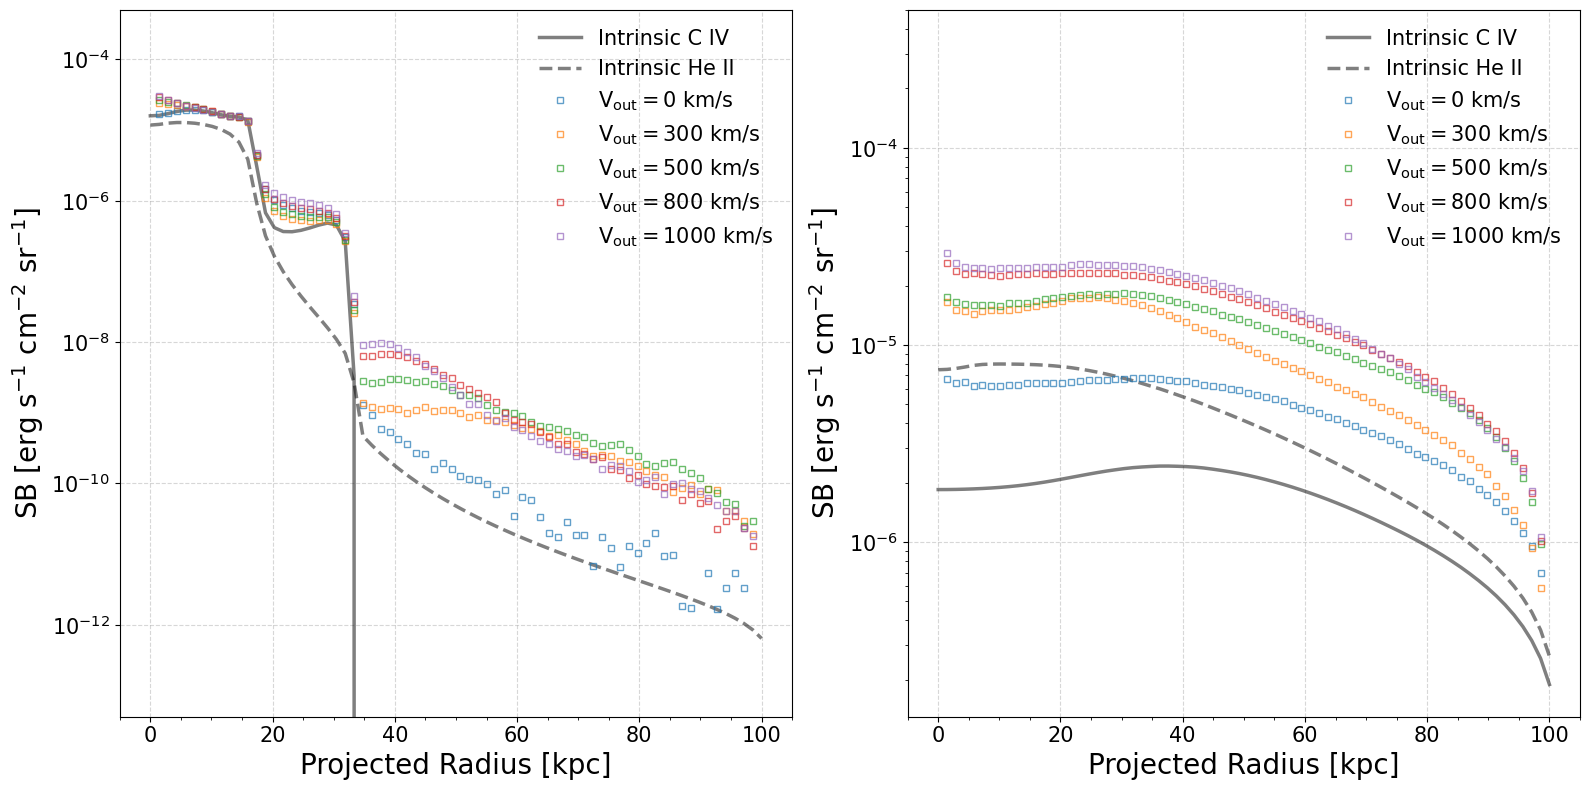

In [7]:
from RT_v1 import *
fig = plt.figure(1,figsize=(16,8))

path_RT = os.path.expanduser(r"~/CIV_RT_scat_data/SB_CIV")

Column_density_order= 22.0
metals = 1.0
V_out = 500
V_emit = 3000  # km/s; Gaussian sigma velocity라고 가정
V_rand = 30
geo = "NEB"

plt.subplot(121)

Lumin = 44.0

atom = "CIV"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV')

atom = "HeII"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II')



V_out = np.array([0, 300, 500, 800, 1000])
for vv in V_out:
    radius, Total_CIV = total_Scattered_CIV(path_RT, vv, V_emit, V_rand, Lumin, metals, Column_density_order)
    plt.plot(
        radius,
        Total_CIV,
        marker='s',
        linestyle='',
        markersize=5,
        markerfacecolor='none',
        alpha=0.7,
        label=fr'$\rm V_{{\rm out}}={vv:<.0f}\ \mathrm{{km/s}}$'
    )






plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.xticks(fontsize=15)

plt.ylabel(r'$\rm SB~[erg \ s^{-1} \ cm^{-2} \ sr^{-1}]$', fontsize=20)
plt.yticks(fontsize=15)
plt.ylim(ymax=5e-4,ymin=5e-14)
plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)
plt.minorticks_on()


plt.subplot(122)


Lumin = 46.0


atom = "CIV"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV')

atom = "HeII"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
plt.plot(radius_int, intrinsic_brightness,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II')



V_out = np.array([0, 300, 500, 800, 1000])
for vv in V_out:
    radius, Total_CIV = total_Scattered_CIV(path_RT, vv, V_emit, V_rand, Lumin, metals, Column_density_order)
    plt.plot(
        radius,
        Total_CIV,
        marker='s',
        linestyle='',
        markersize=5,
        markerfacecolor='none',
        alpha=0.7,
        label=fr'$\rm V_{{\rm out}}={vv:<.0f}\ \mathrm{{km/s}}$'
    )






plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.xticks(fontsize=15)

plt.ylabel(r'$\rm SB~[erg \ s^{-1} \ cm^{-2} \ sr^{-1}]$', fontsize=20)
plt.yticks(fontsize=15)
plt.ylim(ymax=5e-4,ymin=1.3e-7)
plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)
plt.minorticks_on()


plt.tight_layout()
# plt.savefig('/home/jinlim/V_out_various_SB.pdf', bbox_inches='tight')


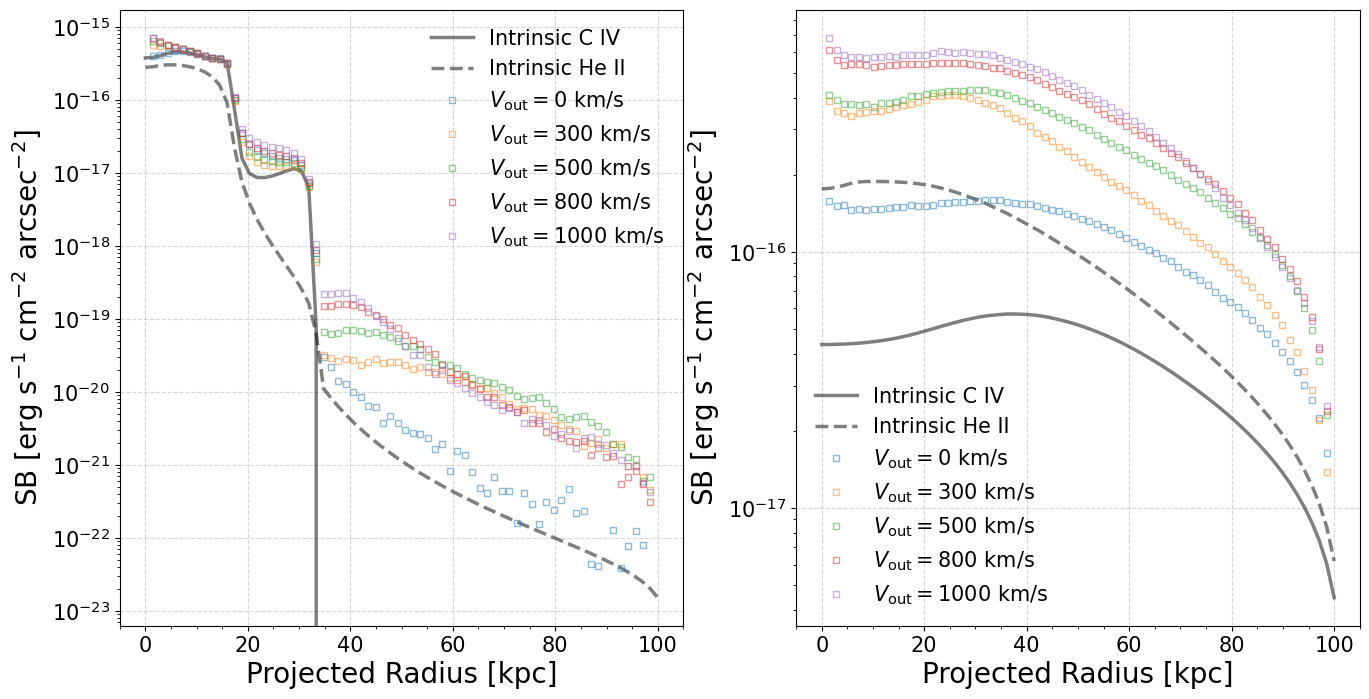

In [8]:
from RT_v1 import *
fig = plt.figure(1,figsize=(16,8))

path_RT = os.path.expanduser(r"~/CIV_RT_scat_data/SB_CIV")

Column_density_order= 22.0
metals = 1.0
V_out = 500
V_emit = 3000  # km/s; Gaussian sigma velocity라고 가정
V_rand = 30
geo = "NEB"

z = 0.0

plt.subplot(121)


Lumin = 44.0


atom = "CIV"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
SB_arc = sr_to_arcsec_2(intrinsic_brightness, z)
plt.plot(radius_int, SB_arc,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV')

atom = "HeII"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
SB_arc = sr_to_arcsec_2(intrinsic_brightness, z)
plt.plot(radius_int, SB_arc,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II')



V_out = np.array([0, 300, 500, 800, 1000])
for vv in V_out:
    radius, Total_CIV = total_Scattered_CIV(path_RT, vv, V_emit, V_rand, Lumin, metals, Column_density_order)
    SB_arc = sr_to_arcsec_2(Total_CIV, z)
    plt.plot(
        radius,
        SB_arc,
        marker='s',
        linestyle='',
        markersize=5,
        markerfacecolor='none',
        alpha=0.5,
        label=fr'$V_{{\rm out}}={vv:<.0f}\ \mathrm{{km/s}}$'
    )






plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.xticks(fontsize=15)

plt.ylabel(r'$\rm SB~[erg \ s^{-1} \ cm^{-2} \ arcsec^{-2}]$', fontsize=20)
plt.yticks(fontsize=15)
# plt.ylim(ymax=5e-4,ymin=5e-14)
plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)
plt.minorticks_on()


plt.subplot(122)


Lumin = 46.0

atom = "CIV"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
SB_arc = sr_to_arcsec_2(intrinsic_brightness, z)
plt.plot(radius_int, SB_arc,'k-',alpha=0.5,lw=2.5,label='Intrinsic C IV')

atom = "HeII"
radius_int, intrinsic_brightness= spatial_distribution_CLOUDY(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,metals,Column_density_order)
SB_arc = sr_to_arcsec_2(intrinsic_brightness, z)
plt.plot(radius_int, SB_arc,'k--',alpha=0.5,lw=2.5,label='Intrinsic He II')



V_out = np.array([0, 300, 500, 800, 1000])
for vv in V_out:
    radius, Total_CIV = total_Scattered_CIV(path_RT, vv, V_emit, V_rand, Lumin, metals, Column_density_order)
    SB_arc = sr_to_arcsec_2(Total_CIV, z)
    plt.plot(
        radius,
        SB_arc,
        marker='s',
        linestyle='',
        markersize=5,
        markerfacecolor='none',
        alpha=0.5,
        label=fr'$V_{{\rm out}}={vv:<.0f}\ \mathrm{{km/s}}$'
    )






plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.xticks(fontsize=15)

plt.ylabel(r'$\rm SB~[erg \ s^{-1} \ cm^{-2} \ arcsec^{-2}]$', fontsize=20)
plt.yticks(fontsize=15)
# plt.ylim(ymax=5e-4,ymin=5e-7)
plt.yscale('log')

plt.legend(frameon=False,fontsize=15)
plt.grid(True,linestyle='--',alpha=0.5)
plt.minorticks_on()



